In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Thay đổi đường dẫn này sao cho đúng với thư mục bạn vừa tạo trên Drive
DATA_DIR = '/content/drive/MyDrive/HomeCreditProject data '

# Kiểm tra xem Colab đã thấy file chưa
print("Các file có trong thư mục:", os.listdir(DATA_DIR))

Mounted at /content/drive
Các file có trong thư mục: ['README.md', 'HomeCredit_columns_description.csv', 'POS_CASH_balance.csv', 'application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'previous_application.csv', 'sample_submission.csv']


# Production-Ready Feature Engineering Pipeline
## Home Credit Default Risk

In [ ]:
# Only needed on Colab/Kaggle kernels
!chmod 600 kaggle.json
!kaggle competitions download -c home-credit-default-risk
!unzip -q home-credit-default-risk.zip

chmod: cannot access 'kaggle.json': No such file or directory
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
unzip:  cannot find or open home-credit-default-risk.zip, home-credit-default-risk.zip.zip or home-credit-default-risk.zip.ZIP.


In [ ]:
!pip install -q catboost lightgbm xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [ ]:
import os, gc, re, time
import pandas as pd
import numpy as np
import xgboost as xgb
from contextlib import contextmanager
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from catboost import CatBoostClassifier

@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object and col_type.name != 'category':
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(df.memory_usage().sum() / 1024**2, 100*(start_mem - (df.memory_usage().sum() / 1024**2))/start_mem))
    return df

DATA_DIR = '/content/drive/MyDrive/HomeCreditProject data '

## 1. Application Table Features
Implementing domain ratios and basic cleaning.

In [ ]:
def one_hot_encoder(df, nan_as_category=True):
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

def application_train_test(num_rows=None):
    df = pd.read_csv(os.path.join(DATA_DIR, 'application_train.csv'), nrows=num_rows)
    test_df = pd.read_csv(os.path.join(DATA_DIR, 'application_test.csv'), nrows=num_rows)
    df = pd.concat([df, test_df], axis=0).reset_index(drop=True)
    df = df[df['CODE_GENDER'] != 'XNA']

    for bin_feature in ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        df[bin_feature], _ = pd.factorize(df[bin_feature])

    df, cat_cols = one_hot_encoder(df)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
    df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    return reduce_mem_usage(df)

def bureau_and_balance(num_rows=None):
    bb = pd.read_csv(os.path.join(DATA_DIR, 'bureau_balance.csv'), nrows=num_rows)
    bb, bb_cat = one_hot_encoder(bb)
    bb_aggregations = {'MONTHS_BALANCE': ['min', 'max', 'size']}
    for col in bb_cat: bb_aggregations[col] = ['mean']
    bb_agg = bb.groupby('SK_ID_BUREAU').agg(bb_aggregations)
    bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])

    bureau = pd.read_csv(os.path.join(DATA_DIR, 'bureau.csv'), nrows=num_rows)
    bureau, bureau_cat = one_hot_encoder(bureau)
    bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
    bureau = bureau.drop(['SK_ID_BUREAU'], axis=1)

    num_aggregations = {
        'DAYS_CREDIT': ['min', 'max', 'mean', 'var'], 'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'DAYS_CREDIT_UPDATE': ['mean'], 'CREDIT_DAY_OVERDUE': ['max', 'mean'], 'AMT_CREDIT_MAX_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum'], 'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['mean'], 'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
        'AMT_ANNUITY': ['max', 'mean'], 'CNT_CREDIT_PROLONG': ['sum'], 'MONTHS_BALANCE_SIZE': ['mean', 'sum']
    }
    cat_aggregations = {col: ['mean'] for col in bureau_cat}
    for col in bb_agg.columns: cat_aggregations[col] = ['mean']

    bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    bureau_agg.columns = pd.Index(['BUREAU_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])

    active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
    active_agg = active.groupby('SK_ID_CURR').agg(num_aggregations)
    active_agg.columns = pd.Index(['ACTIVE_' + e[0] + "_" + e[1].upper() for e in active_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(active_agg, how='left', on='SK_ID_CURR')

    closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
    closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggregations)
    closed_agg.columns = pd.Index(['CLOSED_' + e[0] + "_" + e[1].upper() for e in closed_agg.columns.tolist()])
    bureau_agg = bureau_agg.join(closed_agg, how='left', on='SK_ID_CURR')
    return reduce_mem_usage(bureau_agg)

def previous_applications(num_rows=None):
    prev = pd.read_csv(os.path.join(DATA_DIR, 'previous_application.csv'), nrows=num_rows)
    prev, cat_cols = one_hot_encoder(prev)
    prev['DAYS_FIRST_DRAWING'] = prev['DAYS_FIRST_DRAWING'].replace(365243, np.nan)
    prev['DAYS_FIRST_DUE'] = prev['DAYS_FIRST_DUE'].replace(365243, np.nan)
    prev['DAYS_LAST_DUE_1ST_VERSION'] = prev['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan)
    prev['DAYS_LAST_DUE'] = prev['DAYS_LAST_DUE'].replace(365243, np.nan)
    prev['DAYS_TERMINATION'] = prev['DAYS_TERMINATION'].replace(365243, np.nan)
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']

    num_aggregations = {
        'AMT_ANNUITY': ['min', 'max', 'mean'], 'AMT_APPLICATION': ['min', 'max', 'mean'],
        'AMT_CREDIT': ['min', 'max', 'mean'], 'APP_CREDIT_PERC': ['min', 'max', 'mean', 'var'],
        'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'], 'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
        'HOUR_APPR_PROCESS_START': ['min', 'max', 'mean'], 'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'DAYS_DECISION': ['min', 'max', 'mean'], 'CNT_PAYMENT': ['mean', 'sum'],
    }
    cat_aggregations = {col: ['mean'] for col in cat_cols}
    prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])

    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    approved_agg = approved.groupby('SK_ID_CURR').agg(num_aggregations)
    approved_agg.columns = pd.Index(['APPROVED_' + e[0] + "_" + e[1].upper() for e in approved_agg.columns.tolist()])
    prev_agg = prev_agg.join(approved_agg, how='left', on='SK_ID_CURR')

    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    refused_agg = refused.groupby('SK_ID_CURR').agg(num_aggregations)
    refused_agg.columns = pd.Index(['REFUSED_' + e[0] + "_" + e[1].upper() for e in refused_agg.columns.tolist()])
    prev_agg = prev_agg.join(refused_agg, how='left', on='SK_ID_CURR')
    return reduce_mem_usage(prev_agg)

def pos_cash(num_rows=None):
    pos = pd.read_csv(os.path.join(DATA_DIR, 'POS_CASH_balance.csv'), nrows=num_rows)
    pos, cat_cols = one_hot_encoder(pos)
    aggregations = {
        'MONTHS_BALANCE': ['max', 'mean', 'size'], 'SK_DPD': ['max', 'mean'], 'SK_DPD_DEF': ['max', 'mean']
    }
    for col in cat_cols: aggregations[col] = ['mean']
    pos_agg = pos.groupby('SK_ID_CURR').agg(aggregations)
    pos_agg.columns = pd.Index(['POS_' + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])
    pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()
    return reduce_mem_usage(pos_agg)

def installments_payments(num_rows=None):
    ins = pd.read_csv(os.path.join(DATA_DIR, 'installments_payments.csv'), nrows=num_rows)
    ins, cat_cols = one_hot_encoder(ins)
    ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
    ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
    ins['DPD'] = (ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']).clip(lower=0)
    ins['DBD'] = (ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']).clip(lower=0)

    aggregations = {
        'NUM_INSTALMENT_VERSION': ['nunique'], 'DPD': ['max', 'mean', 'sum'], 'DBD': ['max', 'mean', 'sum'],
        'PAYMENT_PERC': ['max', 'mean', 'sum', 'var'], 'PAYMENT_DIFF': ['max', 'mean', 'sum', 'var'],
        'AMT_INSTALMENT': ['max', 'mean', 'sum'], 'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
        'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum']
    }
    for col in cat_cols: aggregations[col] = ['mean']
    ins_agg = ins.groupby('SK_ID_CURR').agg(aggregations)
    ins_agg.columns = pd.Index(['INS_' + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
    ins_agg['INS_COUNT'] = ins.groupby('SK_ID_CURR').size()
    return reduce_mem_usage(ins_agg)

def credit_card_balance(num_rows=None):
    cc = pd.read_csv(os.path.join(DATA_DIR, 'credit_card_balance.csv'), nrows=num_rows)
    cc, cat_cols = one_hot_encoder(cc)
    cc = cc.drop(['SK_ID_PREV'], axis=1)
    cc_agg = cc.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum', 'var'])
    cc_agg.columns = pd.Index(['CC_' + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])
    cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()
    return reduce_mem_usage(cc_agg)

## 3. Advanced Feature: KNN Target Mean
We find neighbors in `EXT_SOURCE` space and take their target average.

In [ ]:
def add_knn_features(train_df, test_df, n_neighbors=500):
    features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    data = pd.concat([train_df[features], test_df[features]]).fillna(0.5)
    data_scaled = StandardScaler().fit_transform(data)

    train_scaled = data_scaled[:len(train_df)]
    test_scaled = data_scaled[len(train_df):]

    knn = NearestNeighbors(n_neighbors=n_neighbors, n_jobs=-1).fit(train_scaled)
    y = train_df['TARGET'].values

    train_neighbors = knn.kneighbors(train_scaled, return_distance=False)
    test_neighbors = knn.kneighbors(test_scaled, return_distance=False)

    # Explicit assignment with .loc to avoid SettingWithCopyWarning
    train_df.loc[:, 'KNN_TARGET_MEAN'] = [y[idx].mean() for idx in train_neighbors]
    test_df.loc[:, 'KNN_TARGET_MEAN'] = [y[idx].mean() for idx in test_neighbors]
    return train_df, test_df

## 5. Model Training (Top 1 Standard: Stratified 5-Fold)
Diversity and robust CV are key. We implement a Stratified 5-Fold cross-validation loop with LightGBM, tracking Folder-wise AUC and Out-of-Fold (OOF) scores.

In [ ]:
from xgboost.callback import EarlyStopping
save_dir = '/content/drive/MyDrive/HomeCreditProject/models'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

def train_model(train_df, test_df, model_type='lgbm'):
    os.makedirs('models', exist_ok=True)
    train_df = train_df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '_', x))
    test_df = test_df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '_', x))
    feats = [f for f in train_df.columns if f not in ['TARGET', 'SK_ID_CURR', 'index']]

    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(train_df.shape[0])
    sub_preds = np.zeros(test_df.shape[0])

    for n_fold, (train_idx, valid_idx) in enumerate(folds.split(train_df[feats], train_df['TARGET'])):
        train_x, train_y = train_df[feats].iloc[train_idx], train_df['TARGET'].iloc[train_idx]
        valid_x, valid_y = train_df[feats].iloc[valid_idx], train_df['TARGET'].iloc[valid_idx]

        if model_type == 'lgbm':
            clf = LGBMClassifier(n_estimators=10000, learning_rate=0.02, num_leaves=34, colsample_bytree=0.9, subsample=0.8, max_depth=8, reg_alpha=.1, reg_lambda=.1, min_split_gain=.01, min_child_weight=40, silent=-1, verbose=-1, device = "gpu")
            clf.fit(train_x, train_y, eval_set=[(valid_x, valid_y)], eval_metric='auc', callbacks=[early_stopping(200), log_evaluation(200)])
            oof_preds[valid_idx] = clf.predict_proba(valid_x)[:, 1]
            sub_preds += clf.predict_proba(test_df[feats])[:, 1] / folds.n_splits
            clf.booster_.save_model(f'{save_dir}/lgbm_fold_{n_fold+1}.txt')

        elif model_type == 'xgb':
            dtrain = xgb.DMatrix(train_x, label=train_y)
            dvalid = xgb.DMatrix(valid_x, label=valid_y)
            params = {
                'objective': 'binary:logistic',
                'eval_metric': 'auc',
                'tree_method': 'hist',
                'device': 'cuda',
                'learning_rate': 0.02,
                'max_depth': 6
            }
            model = xgb.train(params, dtrain, num_boost_round=10000, evals=[(dvalid, 'valid')], early_stopping_rounds=100, verbose_eval=200)
            oof_preds[valid_idx] = model.predict(dvalid)
            sub_preds += model.predict(xgb.DMatrix(test_df[feats])) / folds.n_splits
            model.save_model(f'{save_dir}/xgb_fold_{n_fold+1}.json')

        elif model_type == 'cat':
            clf = CatBoostClassifier(iterations=10000, task_type='GPU', verbose=200)
            clf.fit(train_x, train_y, eval_set=(valid_x, valid_y), early_stopping_rounds=50)
            oof_preds[valid_idx] = clf.predict_proba(valid_x)[:, 1]
            sub_preds += clf.predict_proba(test_df[feats])[:, 1] / folds.n_splits
            clf.save_model(f'{save_dir}/cat_fold_{n_fold+1}.cbm')

        print('Fold %2d AUC : %.6f' % (n_fold + 1, roc_auc_score(valid_y, oof_preds[valid_idx])))
        gc.collect()

    print('Full %s AUC score %.6f' % (model_type, roc_auc_score(train_df['TARGET'], oof_preds)))
    return sub_preds, oof_preds

## 6. Execution & Model Export

In [ ]:
c_train, c_test = 'train_cache.parquet', 'test_cache.parquet'

if os.path.exists(c_train):
    train, test = pd.read_parquet(c_train), pd.read_parquet(c_test)
    print("Cache Loaded!")
else:
    with timer("Process application tables"): df = application_train_test()
    with timer("Process bureau tables"):
        df = df.join(bureau_and_balance(), how='left', on='SK_ID_CURR')
        gc.collect()
    with timer("Process previous apps"):
        df = df.join(previous_applications(), how='left', on='SK_ID_CURR')
        gc.collect()
    with timer("Process POS, CC, Install"):
        df = df.join(pos_cash(), how='left', on='SK_ID_CURR')
        df = df.join(installments_payments(), how='left', on='SK_ID_CURR')
        df = df.join(credit_card_balance(), how='left', on='SK_ID_CURR')
        gc.collect()

    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    train = df[df['TARGET'].notnull()].copy()
    test = df[df['TARGET'].isnull()].copy()
    train, test = add_knn_features(train, test)
    train.to_parquet(c_train, index=False); test.to_parquet(c_test, index=False)

print("Train shape: {}, test shape: {}".format(train.shape, test.shape))

/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:


Mem. usage decreased to 170.21 Mb (53.0% reduction)
Process application tables - done in 11s


/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning:

Mem. usage decreased to 89.53 Mb (65.7% reduction)
Process bureau tables - done in 26s


/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning:

Mem. usage decreased to 199.71 Mb (69.1% reduction)
Process previous apps - done in 27s
Mem. usage decreased to 13.83 Mb (71.7% reduction)


/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning:

Mem. usage decreased to 34.00 Mb (51.4% reduction)


/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_857/1236898893.py:35: RuntimeWarning:

Mem. usage decreased to 39.90 Mb (60.5% reduction)
Process POS, CC, Install - done in 61s
Train shape: (307507, 806), test shape: (48744, 806)


In [ ]:
def main(model_name = 'lgbm'):
    assert model_name in ['lgbm', 'xgb', 'cat'], "Invalid model name"

    preds, _ = train_model(train, test, model_name)

    submission = pd.DataFrame({
        'SK_ID_CURR': test['SK_ID_CURR'],
        'TARGET': preds
    })

    submission.to_csv(f"submission_{model_name}.csv", index=False)
    print(f"Submission file created using {model_name}: submission_{model_name}.csv")

In [ ]:
main(model_name = 'lgbm')

Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.773621	valid_0's binary_logloss: 0.241566
[400]	valid_0's auc: 0.783378	valid_0's binary_logloss: 0.237965
[600]	valid_0's auc: 0.786539	valid_0's binary_logloss: 0.236858
[800]	valid_0's auc: 0.788031	valid_0's binary_logloss: 0.236357
[1000]	valid_0's auc: 0.788604	valid_0's binary_logloss: 0.236143
[1200]	valid_0's auc: 0.789026	valid_0's binary_logloss: 0.236079
[1400]	valid_0's auc: 0.789226	valid_0's binary_logloss: 0.236067
Early stopping, best iteration is:
[1353]	valid_0's auc: 0.789301	valid_0's binary_logloss: 0.236046
Fold  1 AUC : 0.789301
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.783611	valid_0's binary_logloss: 0.239094
[400]	valid_0's auc: 0.793819	valid_0's binary_logloss: 0.235032
[600]	valid_0's auc: 0.797136	valid_0's binary_logloss: 0.233779
[800]	valid_0's auc: 0.799112	valid_0's binary_logloss: 0.233052
[1000]	valid_0's auc: 0.799822	val

In [ ]:
main(model_name = 'xgb')

[0]	valid-auc:0.72911
[200]	valid-auc:0.77408
[400]	valid-auc:0.78288
[600]	valid-auc:0.78601
[800]	valid-auc:0.78736
[1000]	valid-auc:0.78808
[1200]	valid-auc:0.78829
[1238]	valid-auc:0.78831
Fold  1 AUC : 0.788305
[0]	valid-auc:0.73750
[200]	valid-auc:0.78305
[400]	valid-auc:0.79243
[600]	valid-auc:0.79622
[800]	valid-auc:0.79795
[1000]	valid-auc:0.79921
[1200]	valid-auc:0.79979
[1363]	valid-auc:0.80000
Fold  2 AUC : 0.799999
[0]	valid-auc:0.73159
[200]	valid-auc:0.77328
[400]	valid-auc:0.78186
[600]	valid-auc:0.78587
[800]	valid-auc:0.78758
[1000]	valid-auc:0.78866
[1200]	valid-auc:0.78930
[1400]	valid-auc:0.78945
[1436]	valid-auc:0.78944
Fold  3 AUC : 0.789437
[0]	valid-auc:0.73807
[200]	valid-auc:0.78042
[400]	valid-auc:0.78881
[600]	valid-auc:0.79208
[800]	valid-auc:0.79308
[1000]	valid-auc:0.79358
[1200]	valid-auc:0.79406
[1400]	valid-auc:0.79426
[1600]	valid-auc:0.79445
[1686]	valid-auc:0.79437
Fold  4 AUC : 0.794374
[0]	valid-auc:0.72779
[200]	valid-auc:0.77152
[400]	valid-auc

In [ ]:
main(model_name = 'cat')

Learning rate set to 0.017191
0:	learn: 0.6737892	test: 0.6738068	best: 0.6738068 (0)	total: 279ms	remaining: 46m 33s
200:	learn: 0.2451595	test: 0.2469430	best: 0.2469430 (200)	total: 5.98s	remaining: 4m 51s
400:	learn: 0.2398317	test: 0.2428937	best: 0.2428937 (400)	total: 10.4s	remaining: 4m 8s
600:	learn: 0.2370703	test: 0.2413426	best: 0.2413426 (600)	total: 13.7s	remaining: 3m 34s
800:	learn: 0.2350846	test: 0.2404474	best: 0.2404474 (800)	total: 17s	remaining: 3m 15s
1000:	learn: 0.2333674	test: 0.2397877	best: 0.2397877 (1000)	total: 22.9s	remaining: 3m 26s
1200:	learn: 0.2318630	test: 0.2392965	best: 0.2392965 (1200)	total: 26.1s	remaining: 3m 11s
1400:	learn: 0.2306209	test: 0.2389499	best: 0.2389499 (1400)	total: 29.3s	remaining: 2m 59s
1600:	learn: 0.2294327	test: 0.2386855	best: 0.2386855 (1600)	total: 33.6s	remaining: 2m 56s
1800:	learn: 0.2282527	test: 0.2384504	best: 0.2384503 (1799)	total: 38.4s	remaining: 2m 55s
2000:	learn: 0.2271646	test: 0.2382565	best: 0.2382565 (


Processing Validation scores for LGBM...
Fold 1 AUC: 0.789301
Fold 2 AUC: 0.800351
Fold 3 AUC: 0.793256
Fold 4 AUC: 0.795112
Fold 5 AUC: 0.791062

Processing Validation scores for XGB...
Fold 1 AUC: 0.788305
Fold 2 AUC: 0.799999
Fold 3 AUC: 0.789437
Fold 4 AUC: 0.794374
Fold 5 AUC: 0.789505

Processing Validation scores for CAT...
Fold 1 AUC: 0.786236
Fold 2 AUC: 0.798371
Fold 3 AUC: 0.788156
Fold 4 AUC: 0.792529
Fold 5 AUC: 0.787693


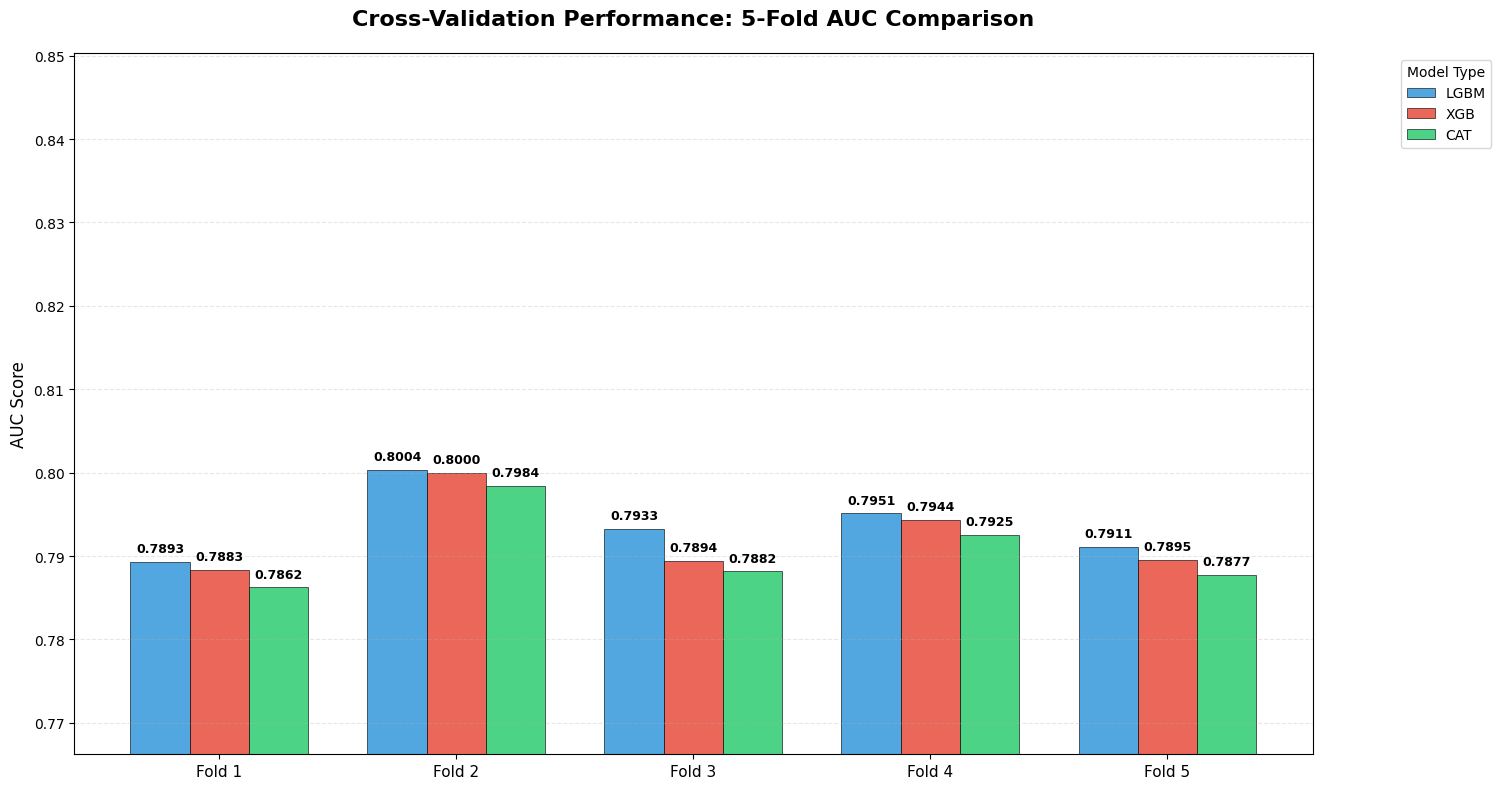

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import re
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

def get_validation_auc_detailed(data_df, model_type='lgbm'):
    data_df = data_df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '_', x))
    feats = [f for f in data_df.columns if f not in ['TARGET', 'SK_ID_CURR', 'index']]

    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_aucs = []

    print(f"\nProcessing Validation scores for {model_type.upper()}...")

    for n_fold, (train_idx, valid_idx) in enumerate(folds.split(data_df[feats], data_df['TARGET'])):
        model_path = f'{save_dir}/{model_type}_fold_{n_fold+1}.txt' if model_type=='lgbm' else \
                     f'{save_dir}/{model_type}_fold_{n_fold+1}.json' if model_type=='xgb' else \
                     f'{save_dir}/{model_type}_fold_{n_fold+1}.cbm'

        if not os.path.exists(model_path):
            continue

        valid_x, valid_y = data_df[feats].iloc[valid_idx], data_df['TARGET'].iloc[valid_idx]

        if model_type == 'lgbm':
            import lightgbm as lgb
            model = lgb.Booster(model_file=model_path)
            preds = model.predict(valid_x)
        elif model_type == 'xgb':
            import xgboost as xgb
            model = xgb.Booster()
            model.load_model(model_path)
            preds = model.predict(xgb.DMatrix(valid_x))
        elif model_type == 'cat':
            from catboost import CatBoostClassifier
            model = CatBoostClassifier()
            model.load_model(model_path)
            preds = model.predict_proba(valid_x)[:, 1]

        auc = roc_auc_score(valid_y, preds)
        fold_aucs.append(auc)
        print(f"Fold {n_fold+1} AUC: {auc:.6f}")

    return fold_aucs

def compare_models_by_fold(results_dict):
    models = list(results_dict.keys())
    n_folds = 5
    n_models = len(models)

    fig, ax = plt.subplots(figsize=(15, 8))
    width = 0.25  # Width of each bar
    x = np.arange(n_folds)  # Fold labels (0, 1, 2, 3, 4)

    colors = {'LGBM': '#3498db', 'XGB': '#e74c3c', 'CAT': '#2ecc71'}

    for i, model_name in enumerate(models):
        # Calculate position for grouped bars
        pos = x + (i - (n_models - 1) / 2) * width
        scores = results_dict[model_name]

        rects = ax.bar(pos, scores, width, label=model_name, color=colors.get(model_name, 'gray'), alpha=0.85, edgecolor='black', linewidth=0.5)

        # Add score labels on top
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=0)

    ax.set_ylabel('AUC Score', fontsize=12)
    ax.set_title('Cross-Validation Performance: 5-Fold AUC Comparison', fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Fold {i+1}' for i in range(n_folds)], fontsize=11)
    ax.legend(title="Model Type", loc='upper right', bbox_to_anchor=(1.15, 1))

    # Dynamic Y-axis scale to highlight differences
    all_scores = [s for scores in results_dict.values() for s in scores]
    if all_scores:
        ax.set_ylim(min(all_scores) - 0.02, max(all_scores) + 0.05)

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Execution: Gather detailed results per fold
detailed_results = {}
for mtype in ['lgbm', 'xgb', 'cat']:
    fold_scores = get_validation_auc_detailed(train, mtype)
    if fold_scores:
        detailed_results[mtype.upper()] = fold_scores

if detailed_results:
    compare_models_by_fold(detailed_results)

In [ ]:
import pandas as pd

# Đọc lại các file kết quả bạn đã tải về máy (hoặc đang có trên Colab)
sub_lgbm = pd.read_csv('submission_lgbm.csv')
sub_xgb = pd.read_csv('submission_xgb.csv')
sub_cat = pd.read_csv('submission_cat.csv')

# Kết hợp theo trọng số tối ưu
# LGBM (0.792) mạnh nhất nên chiếm 40%, hai ông còn lại mỗi ông 30%
ensemble_target = (sub_lgbm['TARGET'] * 0.4) + (sub_xgb['TARGET'] * 0.3) + (sub_cat['TARGET'] * 0.3)

submission = pd.DataFrame({
    'SK_ID_CURR': sub_lgbm['SK_ID_CURR'],
    'TARGET': ensemble_target
})

submission.to_csv('submission_final_ensemble.csv', index=False)

In [ ]:
import pandas as pd

# Giả sử bạn đã chạy 3 lệnh main ở Cách 1 để có 3 file csv
sub_lgbm = pd.read_csv('submission_lgbm.csv')
sub_xgb = pd.read_csv('submission_xgb.csv')
sub_cat = pd.read_csv('submission_cat.csv')

# Kết hợp theo trọng số (LGBM thường mạnh nhất nên ưu tiên hơn)
final_target = (sub_lgbm['TARGET'] * 0.4) + (sub_xgb['TARGET'] * 0.3) + (sub_cat['TARGET'] * 0.3)

submission_final = pd.DataFrame({
    'SK_ID_CURR': sub_lgbm['SK_ID_CURR'],
    'TARGET': final_target
})

submission_final.to_csv('submission_final_ensemble.csv', index=False)

from google.colab import files
files.download('submission_final_ensemble.csv')
print("Đã tạo và tải file Ensemble thành công!")